In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

BASE_DS_SAVE_PATH = '../../data/mtssquad/base_dataset.csv'
QA_DS_SAVE_PATH = '../../data/mtssquad/qa_dataset.csv'
CONTEXTS_SAVE_PATH = '../../data/mtssquad/contexts.csv'

DOWNLOAD_URL = "hf://datasets/MTS-AI-SearchSkill/MTSBerquad/MTSBerquad_LFQA_Dataset_Pretty.csv" #"hf://datasets/MTS-AI-SearchSkill/MTSBerquad/MTSBerquad_LFQA_Dataset.csv"

In [6]:
def print_df_stat(df):
    print("===Статистика по исходному датасету===")
    print("Количество строк в датасете: ", df.shape[0])
    print("Количество уникальных context-текстов: ", len(df['context'].unique()))
    print("Количество уникальных question-текстов: ", len(df['question'].unique()))
    print("Количество уникальных answer-текстов: ", len(df['answer'].unique()))

In [7]:
df = pd.read_csv(DOWNLOAD_URL)

In [8]:
print_df_stat(df)

===Статистика по исходному датасету===
Количество строк в датасете:  52748
Количество уникальных context-текстов:  9032
Количество уникальных question-текстов:  50695
Количество уникальных answer-текстов:  44053


In [9]:
df.to_csv(BASE_DS_SAVE_PATH, sep=';', index=False)

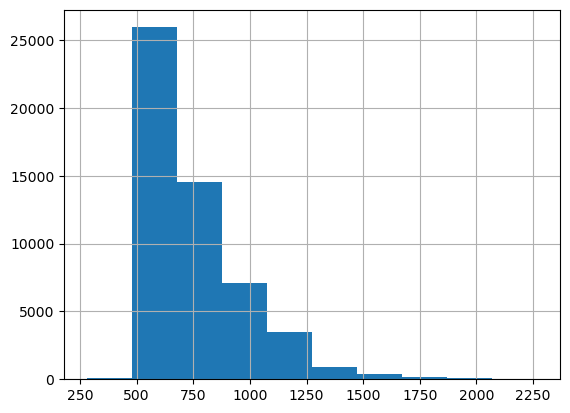

In [10]:
plt.hist(list(map(len, df['context'].tolist())))
plt.grid()
plt.show()

In [11]:
filtered_df = df.drop_duplicates(subset=['question']).reset_index(drop=True)
print(filtered_df.shape)

(50695, 3)


In [12]:
no_answer_idxs = filtered_df[filtered_df['answer'] == 'Нет информации'].index.tolist()

In [13]:
filtered_df = filtered_df[~filtered_df.index.isin(no_answer_idxs)].reset_index(drop=True)
print(filtered_df.shape)

(44371, 3)


In [14]:
contexts_dataset = df['context'].unique().tolist()
print(len(contexts_dataset))

9032


In [15]:
qa_dataset = []
for i in tqdm(range(filtered_df.shape[0])):
    if len(filtered_df['answer']):
        item = [ filtered_df['question'][i], filtered_df['answer'][i], contexts_dataset.index(filtered_df['context'][i])]
        qa_dataset.append(item)
print(filtered_df.shape, len(qa_dataset))

100%|██████████| 44371/44371 [00:01<00:00, 36116.23it/s]

(44371, 3) 44371


In [16]:
contexts_df = pd.DataFrame(contexts_dataset, columns=['context'])
print(contexts_df.shape)

(9032, 1)


In [17]:
qa_df = pd.DataFrame(qa_dataset, columns=['question', 'answer', 'relevant_context_id'])
print(qa_df.shape)

(44371, 3)


In [18]:
qa_df.to_csv(QA_DS_SAVE_PATH, index=False)

In [19]:
contexts_df.to_csv(CONTEXTS_SAVE_PATH, index=False)